In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df = pd.read_csv("ai4i2020.csv")
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [4]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [6]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [7]:
df[df["Tool wear [min]"] == 253]

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
5401,5402,M20261,M,302.6,312.3,1454,54.8,253,1,1,0,0,1,0


In [8]:
df = df.drop("TWF" , axis=1)
df = df.drop("HDF" , axis=1)
df = df.drop("PWF" , axis=1)
df = df.drop("OSF" , axis=1)
df = df.drop("RNF" , axis=1)

In [9]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,1,M14860,M,298.1,308.6,1551,42.8,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0


In [10]:
df["Power"] = df["Rotational speed [rpm]"] * df["Torque [Nm]"]

In [11]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Power
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,66382.8
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,65190.4
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,74001.2
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,56603.5
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,56320.0


In [12]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Power
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,66382.8
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,65190.4
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,74001.2
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,56603.5
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,56320.0


In [13]:
df["Power"].idxmax()

9084

In [14]:
df.loc[9084]

UDI                           9085
Product ID                  L56264
Type                             L
Air temperature [K]          297.2
Process temperature [K]      307.9
Rotational speed [rpm]        1326
Torque [Nm]                   75.4
Tool wear [min]                172
Machine failure                  1
Power                      99980.4
Name: 9084, dtype: object

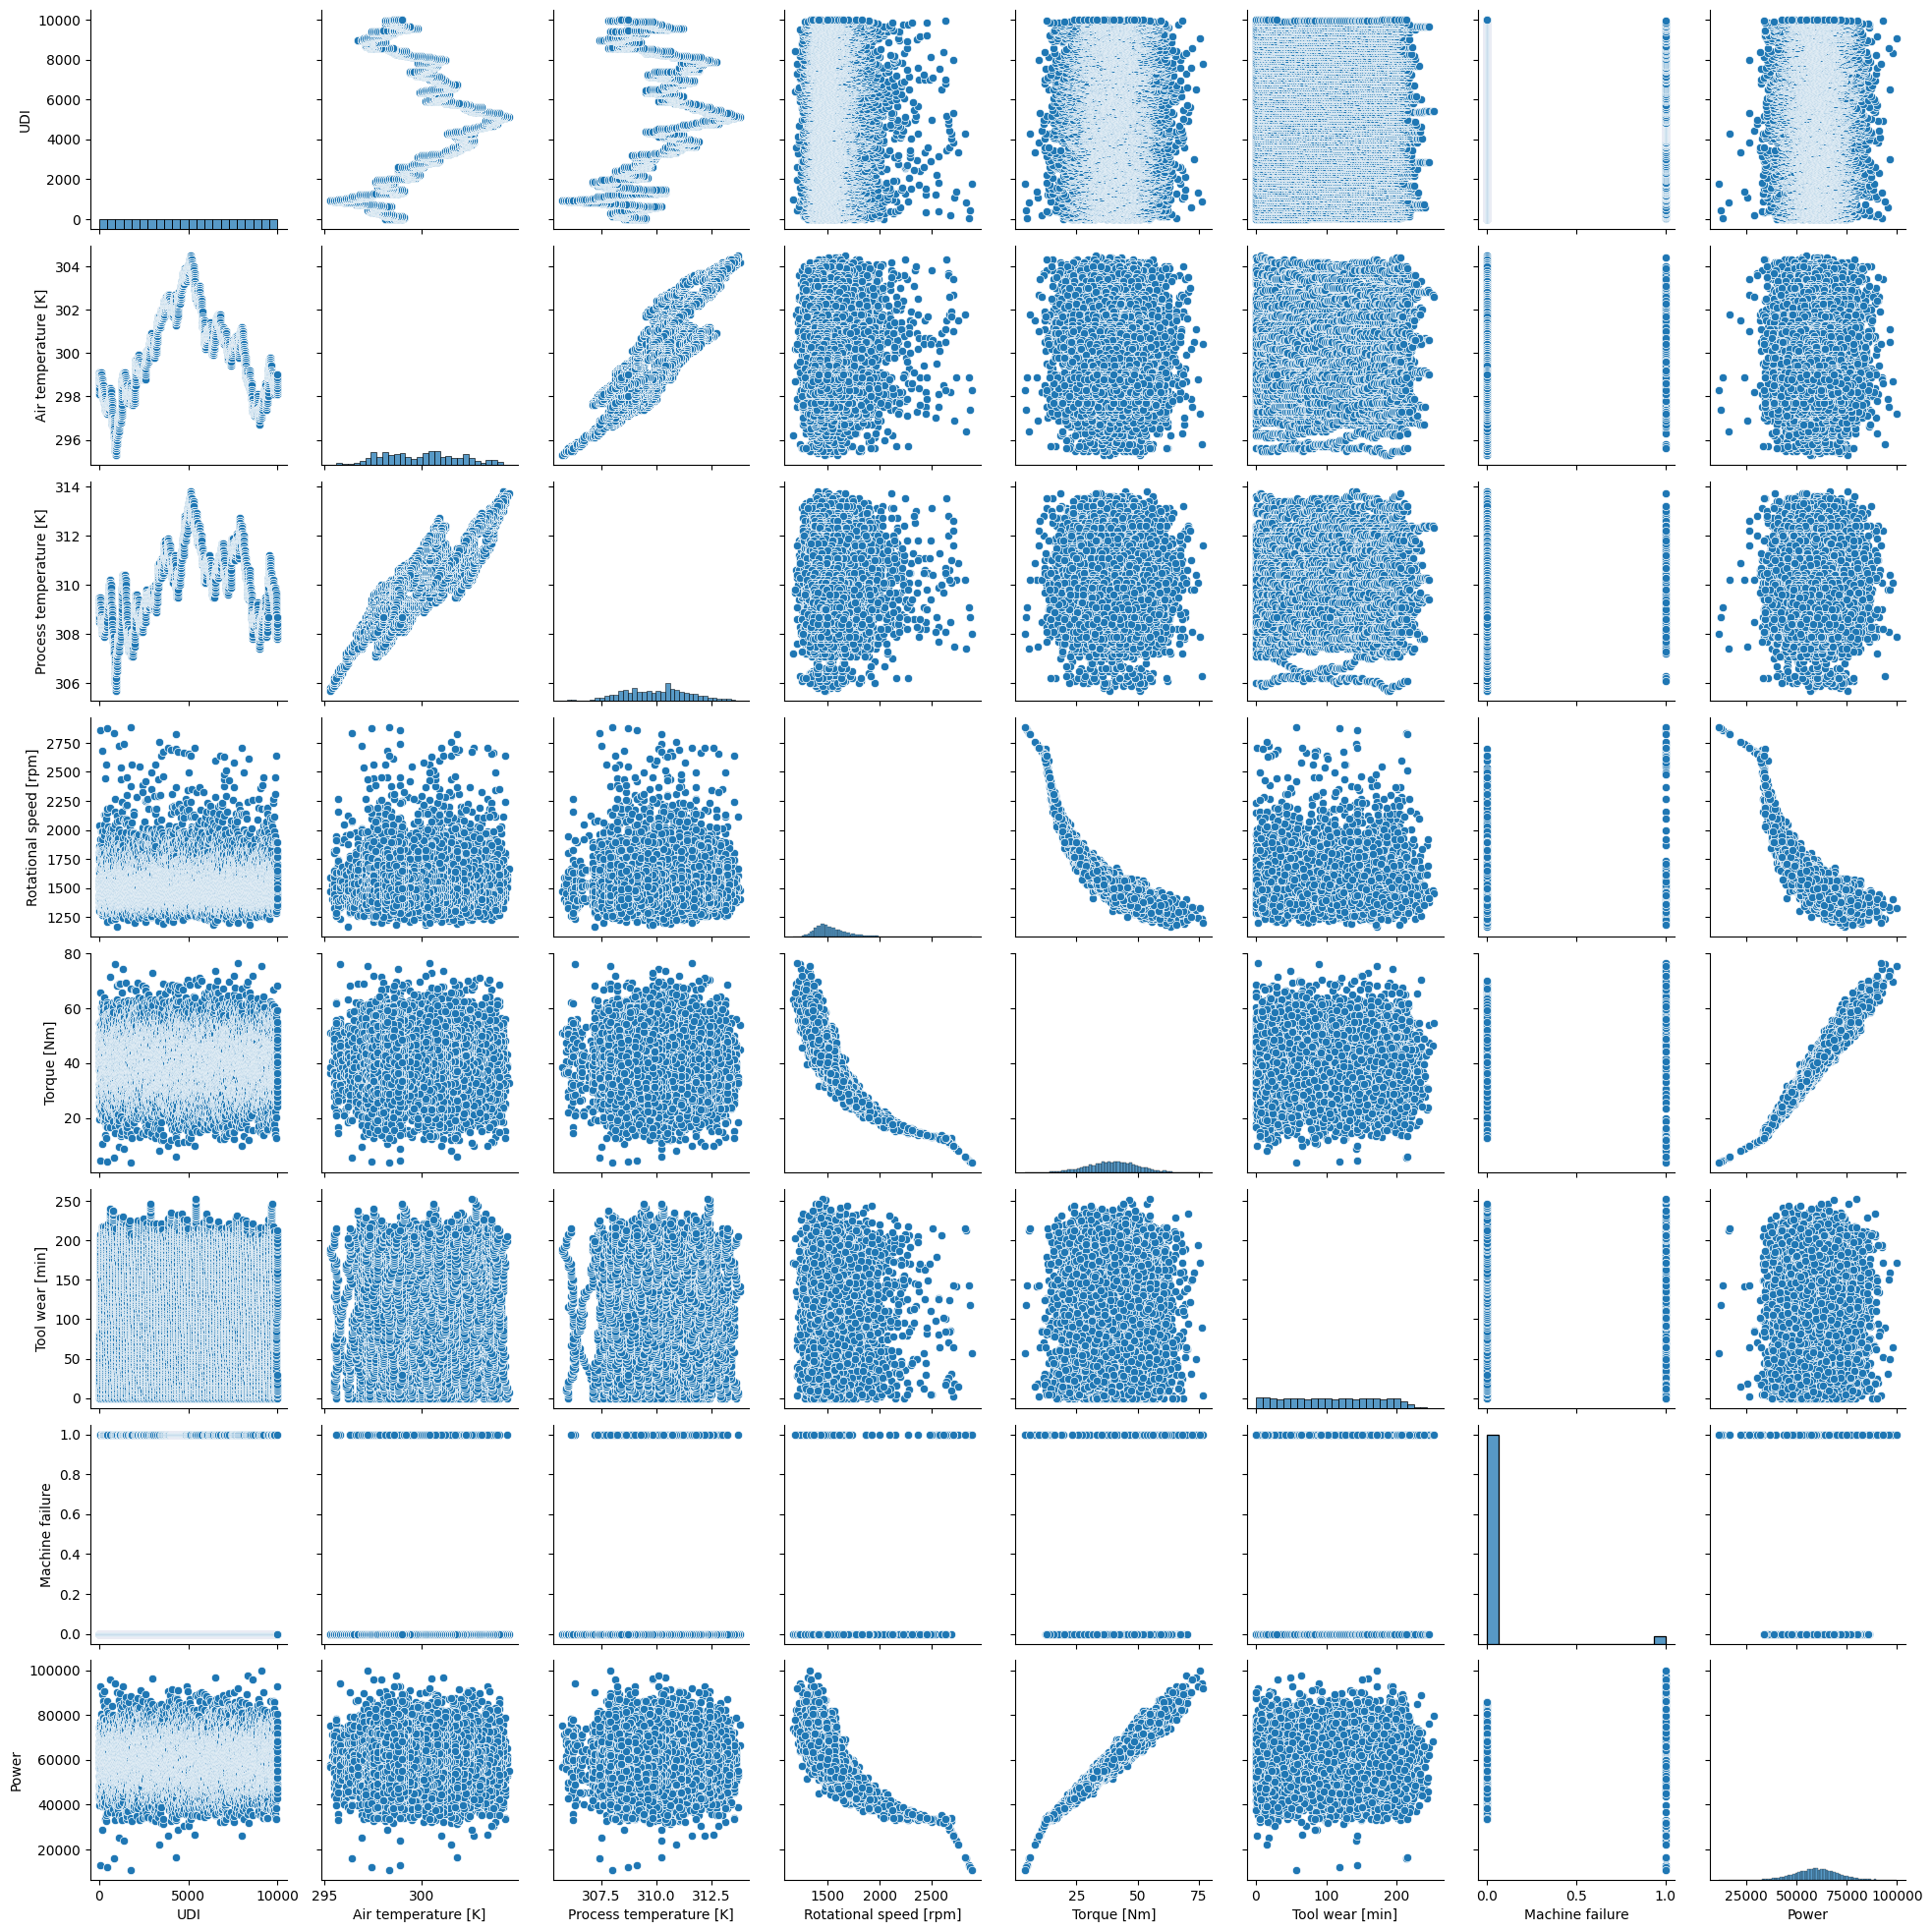

In [15]:
sns.pairplot(df)
plt.show()

In [16]:
df["Air temperature [K]"].corr(df["Process temperature [K]"])

np.float64(0.8761071581166631)

In [17]:
def correlation_for_dropping(df, threshold):
    columns_to_drop = set()
    corr = df.corr(numeric_only=True)
    for i in range(len(corr.columns)):
        for j in range(i):
            if abs(corr.iloc[i, j]) > threshold:
                columns_to_drop.add(corr.columns[i])
    return columns_to_drop

In [18]:
df1 = df.drop("Machine failure" , axis=1)

In [19]:
correlation_for_dropping(df1 , 0.85)

{'Power', 'Process temperature [K]', 'Torque [Nm]'}

In [20]:
print(df['Power'].corr(df['Torque [Nm]']))
print(df['Power'].corr(df["Rotational speed [rpm]"]))

0.9788282708982241
-0.8055837074013531


In [21]:
df = df.drop('Torque [Nm]', axis=1)
df = df.drop('Process temperature [K]', axis=1)

In [22]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Rotational speed [rpm],Tool wear [min],Machine failure,Power
0,1,M14860,M,298.1,1551,0,0,66382.8
1,2,L47181,L,298.2,1408,3,0,65190.4
2,3,L47182,L,298.1,1498,5,0,74001.2
3,4,L47183,L,298.2,1433,7,0,56603.5
4,5,L47184,L,298.2,1408,9,0,56320.0


In [23]:
df["Type"].unique()

array(['M', 'L', 'H'], dtype=object)

In [24]:
df = df.drop("UDI" , axis=1)
df = df.drop("Product ID" , axis=1)

In [25]:
from sklearn.preprocessing import OrdinalEncoder
encoder = OrdinalEncoder(categories=[['L', "M", "H"]])
df["Type"] = encoder.fit_transform(df[['Type']])


In [26]:
df.head()

,Type,Air temperature [K],Rotational speed [rpm],Tool wear [min],Machine failure,Power
0,1.0,298.1,1551,0,0,66382.8
1,0.0,298.2,1408,3,0,65190.4
2,0.0,298.1,1498,5,0,74001.2
3,0.0,298.2,1433,7,0,56603.5
4,0.0,298.2,1408,9,0,56320.0


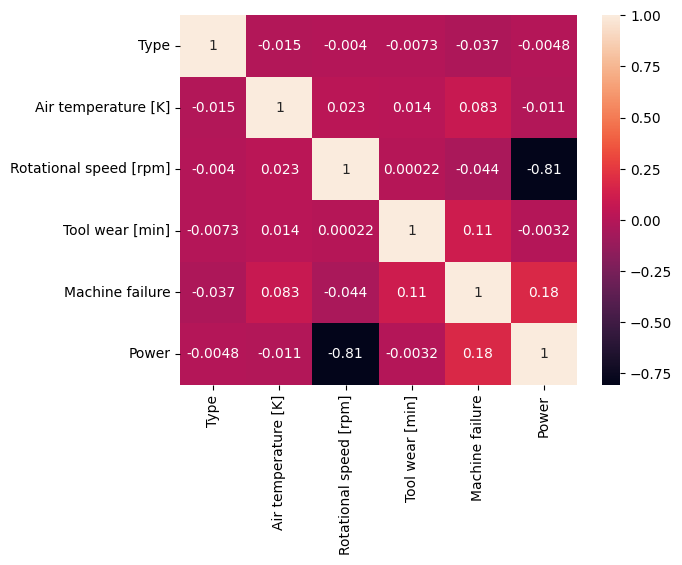

In [27]:
correlation = df.corr(numeric_only=True)
sns.heatmap(correlation , annot=True)
plt.show()

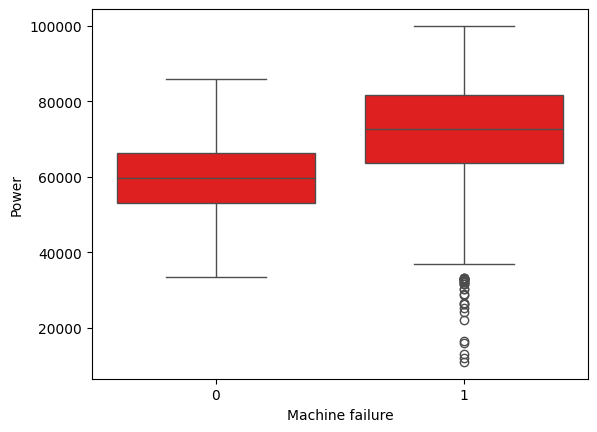

In [28]:
sns.boxplot(data=df , x="Machine failure" , y="Power" ,color="red")
plt.show()

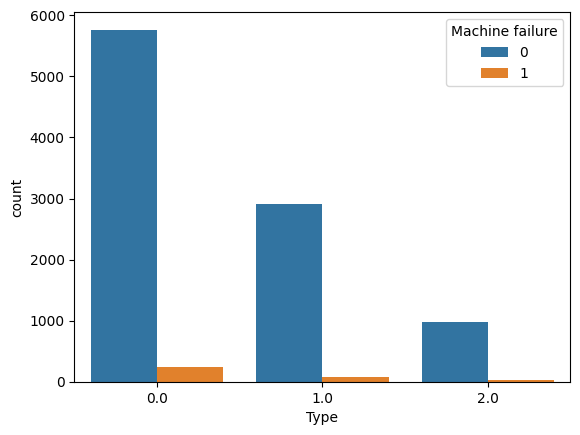

In [29]:
sns.countplot(data=df , x="Type" , hue="Machine failure")
plt.show()

In [30]:
df["Type"].value_counts()

Type
0.0    6000
1.0    2997
2.0    1003
Name: count, dtype: int64

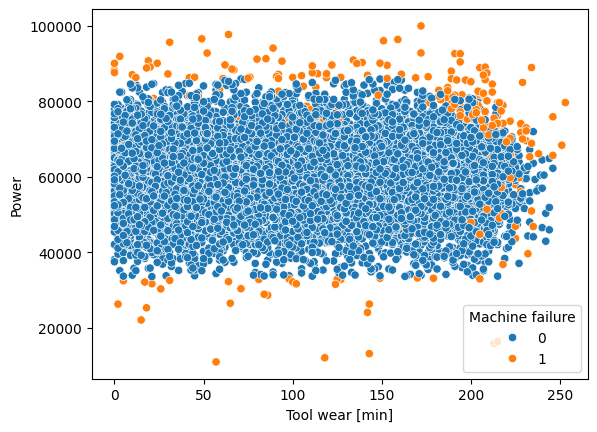

In [31]:
sns.scatterplot(data=df , x="Tool wear [min]" , y="Power" , hue="Machine failure")
plt.show()

In [32]:
df["Type"].value_counts()

Type
0.0    6000
1.0    2997
2.0    1003
Name: count, dtype: int64

In [33]:
df.head()

,Type,Air temperature [K],Rotational speed [rpm],Tool wear [min],Machine failure,Power
0,1.0,298.1,1551,0,0,66382.8
1,0.0,298.2,1408,3,0,65190.4
2,0.0,298.1,1498,5,0,74001.2
3,0.0,298.2,1433,7,0,56603.5
4,0.0,298.2,1408,9,0,56320.0


In [34]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

X = df.drop("Machine failure",axis=1)
y= df["Machine failure"]

X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.25,random_state=15)

oversample = SMOTE()
smote = SMOTE(random_state=15)
X_train_smote,y_train_smote = smote.fit_resample(X_train , y_train)


In [35]:
y_train_smote

0        0
1        0
2        0
3        0
4        0
        ..
14485    1
14486    1
14487    1
14488    1
14489    1
Name: Machine failure, Length: 14490, dtype: int64

In [36]:
scaler = StandardScaler()
X_train_smote_scaler = scaler.fit_transform(X_train_smote)
X_test_scaler = scaler.transform(X_test)

In [37]:
# 1. Regressor değil, Classifier (Sınıflandırıcı) çağırıyoruz
from lazypredict.Supervised import LazyClassifier

# 2. Tembel Sınıflandırıcımızı tanımlıyoruz
clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)

# 3. Kendi ellerinle ilmek ilmek işlediğin o kusursuz verileri arenaya atıyorsun
models, predictions = clf.fit(X_train_smote_scaler, X_test_scaler, y_train_smote, y_test)

# 4. Ve şov başlasın!
print(models)

                               Accuracy  Balanced Accuracy   ROC AUC  \
Model                                                                  
SVC                              0.8920           0.869432  0.940580   
NuSVC                            0.8392           0.853605  0.914104   
AdaBoostClassifier               0.9056           0.847741  0.929816   
LabelPropagation                 0.9072           0.825587  0.915440   
LabelSpreading                   0.9048           0.824346  0.912641   
KNeighborsClassifier             0.9104           0.798516  0.882216   
RandomForestClassifier           0.9600           0.795451  0.919830   
ExtraTreesClassifier             0.9572           0.788257  0.926502   
ExtraTreeClassifier              0.9188           0.774135  0.774135   
DecisionTreeClassifier           0.9372           0.772164  0.772164   
GaussianNB                       0.8536           0.751892  0.834398   
BaggingClassifier                0.9488           0.749438  0.85

In [38]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

In [41]:
param_grid = {
    'C': [100, 10, 1.0, 0.1, 0.01],
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
    'gamma': ['scale', 'auto'],
}

In [47]:
grid = GridSearchCV(estimator= SVC(probability=True) , param_grid=param_grid , cv=5 , verbose=2, n_jobs=-1)
grid.fit(X_train_smote_scaler , y_train_smote)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


GridSearchCV(cv=5, estimator=SVC(probability=True), n_jobs=-1,
             param_grid={'C': [100, 10, 1.0, 0.1, 0.01],
                         'gamma': ['scale', 'auto'],
                         'kernel': ['linear', 'rbf', 'poly', 'sigmoid']},
             verbose=2)

In [48]:
grid.best_params_

{'C': 100, 'gamma': 'auto', 'kernel': 'rbf'}

In [45]:
y_pred = grid.predict(X_test_scaler)

Model AUC Skoru: 0.9274


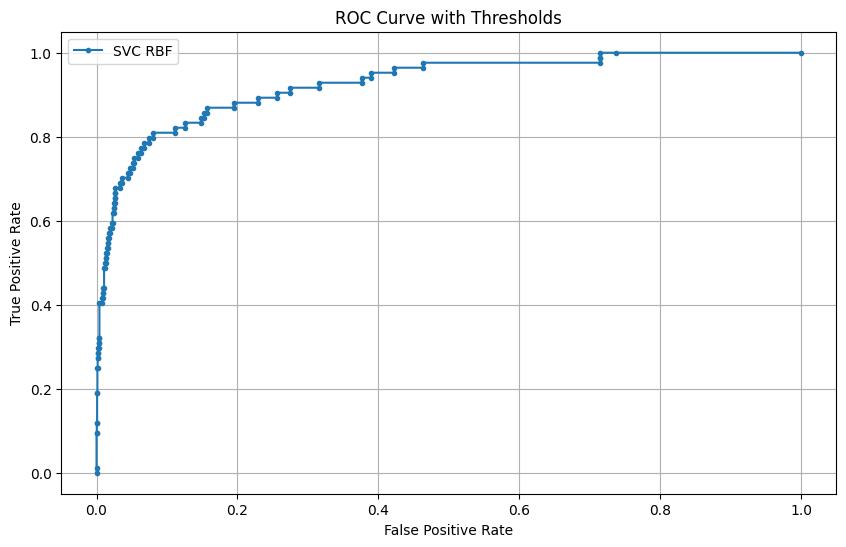


Evaluation using custom threshold = 0.45
[[2237  179]
 [  18   66]]


              precision    recall  f1-score   support

           0       0.99      0.93      0.96      2416
           1       0.27      0.79      0.40        84

    accuracy                           0.92      2500
   macro avg       0.63      0.86      0.68      2500
weighted avg       0.97      0.92      0.94      2500



In [51]:
from sklearn.metrics import roc_auc_score, roc_curve, classification_report, confusion_matrix
import matplotlib.pyplot as plt

# 1. Test verisinin pozitif sınıf olma olasılıklarını alıyoruz
model_prob = grid.predict_proba(X_test_scaler)[:, 1]

# 2. ROC-AUC Skoru
model_auc = roc_auc_score(y_test, model_prob)
print(f"Model AUC Skoru: {model_auc:.4f}")

# 3. ROC Eğrisi için FPR, TPR ve eşikleri hesaplıyoruz
model_fpr, model_tpr, thresholds = roc_curve(y_test, model_prob)

# ROC Eğrisini Çizdirme (Üzerine eşikleri yazdırma opsiyonlu)
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(model_fpr, model_tpr, marker='.', label='SVC RBF')

# Grafiğe eşik değerlerini küçük etiketler olarak eklemek istersen:
#for fpr, tpr, thresh in zip(model_fpr, model_tpr, thresholds):
   # ax.annotate(f'{np.round(thresh, 2)}', (fpr, tpr), textcoords="offset points", xytext=(0,10), ha='center', fontsize=8)

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve with Thresholds')
ax.legend()
ax.grid(True)
plt.show()

# 4. Kendi belirlediğimiz özel eşik değeri (Örn: 0.30 veya 0.20)
custom_threshold = 0.45  

y_pred_custom = (model_prob >= custom_threshold).astype(int)

# 5. Sonuçları Değerlendirme
print(f"\nEvaluation using custom threshold = {custom_threshold}")
print(confusion_matrix(y_test, y_pred_custom))
print("\n")
print(classification_report(y_test, y_pred_custom))